# Student Performance Prediction with Machine Learning

This project develops regression models to predict student final grades using behavioral, demographic, and academic features from a public dataset.

A key goal is to compare two real-world intervention scenarios:

- **With prior-term grades** – higher predictive accuracy, later intervention
- **Without prior-term grades** – lower accuracy, but useful for early risk detection

Models evaluated:
- Linear Regression
- Lasso Regression
- Support Vector Machine (SVR)

Evaluation metrics:
- RMSE
- R²

## Part 1: Technical Implementation

### Name: Ryan Harvey

## Overview

### Machine Learning Task
Suppose you work in the Advising Team for a large Portuguese school system, and your school director has asked you to analyze student data and create a machine learning model to predict a student’s performance based on select features. Your director hopes to use this information to identify students who might need additional assistance and interventions to improve their grades.

Your task is to create a regression model to predict a student's grade. You will need to clean and prepare the data to ensure it is suitable for analysis. After building the model, you will evaluate its performance using appropriate metrics to assess its accuracy and effectiveness.


## Data Loading and Initial Inspection

Begin by importing and inspecting your dataset to ensure it is correctly loaded and understand its structure. This initial step sets the foundation for your analysis and modeling.

1) **Import the Data**: Correctly import your data.
2) **Initial Data Check**: Check the initial data, including size and data types.
3) **Identify the Target**: Identify the target attribute.
4) **Split the Data**: Split your data into training and test sets using the variable names `X_train`, `X_test`, `y_train`, and `y_test`.  Use `test_size=0.2` and `random_state=42`.
5) **Comment Your Code**: Get into the habit of including comments in your code. Comments should explain <u>why</u> decisions were made, while the code should be clean enough to read and understand <u>what</u> the program does. 


In [1]:
import pandas as pd

#Import the Data
students = pd.read_csv('student-mat.csv')

#Initial Data Check: Size and Data Types
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   school       395 non-null    object 
 1   sex          395 non-null    object 
 2   age          383 non-null    float64
 3   address      395 non-null    object 
 4   famsize      395 non-null    object 
 5   Pstatus      395 non-null    object 
 6   Medu         395 non-null    int64  
 7   Fedu         395 non-null    int64  
 8   Mjob         395 non-null    object 
 9   Fjob         395 non-null    object 
 10  reason       395 non-null    object 
 11  guardian     395 non-null    object 
 12  traveltime   395 non-null    int64  
 13  studytime    395 non-null    int64  
 14  failures     395 non-null    int64  
 15  schoolsup    395 non-null    object 
 16  famsup       395 non-null    object 
 17  paid         395 non-null    object 
 18  activities   395 non-null    object 
 19  nursery 

In [2]:
from sklearn.model_selection import train_test_split

#Identify the Target
target = "G3"

#Split the Data
X = students.drop(columns=[target])
y = students[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

## Exploratory Data Analysis
Understanding your data is a crucial step before building any machine learning model. This exploration phase helps you identify patterns, detect anomalies, and uncover insights that will guide your modeling decisions. By thoroughly analyzing and visualizing the data, you can make informed choices on feature selection and preprocessing, ultimately improving your model's performance and reliability.

This section won't be automatically graded, but you must include your analytical insight and screenshots of your plots in the Executive Summary report.

In this section you should:
1) **Study Attributes**: Thoroughly study the training set attributes and their characteristics.
2) **Visualizations**: Use visualizations to effectively analyze and explore your data. Be ready to explain what the visualization shows and why it is important.  
3) **Correlations**: Analyze correlations between your numeric attributes.

*CodeGrade will only have matplotlib and seaborn libraries loaded. You can use other libraries (e.g., Plotly) or use software (e.g., Tableau) for your visualizations, but comment out any code that is not matplotlib or seaborn before submitting to CodeGrade including import statements.*

You will include your analysis and at least three plots in your Executive Summary. Use either screenshots and paste them into your Executive Summary document or the `savefig()` method. Here's example code for saving a plot in different file formats:
```
import matplotlib.pyplot as plt

# Your plotting code here
plt.plot([1, 2, 3, 4], [10, 20, 25, 30])
plt.xlabel('X-axis label')
plt.ylabel('Y-axis label')
plt.title('Sample Plot')

# Save the plot as a PNG file
plt.savefig('my_plot.png')

# Optionally, save in other formats
plt.savefig('my_plot.pdf')
plt.savefig('my_plot.jpg')
```

In [3]:
#Study Attributes
train_df = pd.concat([X_train, y_train.rename("G3")], axis=1)

train_df.info(); train_df.select_dtypes(include="number").describe().T

train_df.select_dtypes(exclude="number").nunique().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
Index: 316 entries, 181 to 102
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   school       316 non-null    object 
 1   sex          316 non-null    object 
 2   age          305 non-null    float64
 3   address      316 non-null    object 
 4   famsize      316 non-null    object 
 5   Pstatus      316 non-null    object 
 6   Medu         316 non-null    int64  
 7   Fedu         316 non-null    int64  
 8   Mjob         316 non-null    object 
 9   Fjob         316 non-null    object 
 10  reason       316 non-null    object 
 11  guardian     316 non-null    object 
 12  traveltime   316 non-null    int64  
 13  studytime    316 non-null    int64  
 14  failures     316 non-null    int64  
 15  schoolsup    316 non-null    object 
 16  famsup       316 non-null    object 
 17  paid         316 non-null    object 
 18  activities   316 non-null    object 
 19  nursery    

Mjob          5
Fjob          5
reason        4
guardian      3
famsup        2
internet      2
higher        2
nursery       2
activities    2
paid          2
school        2
schoolsup     2
sex           2
Pstatus       2
famsize       2
address       2
romantic      2
dtype: int64

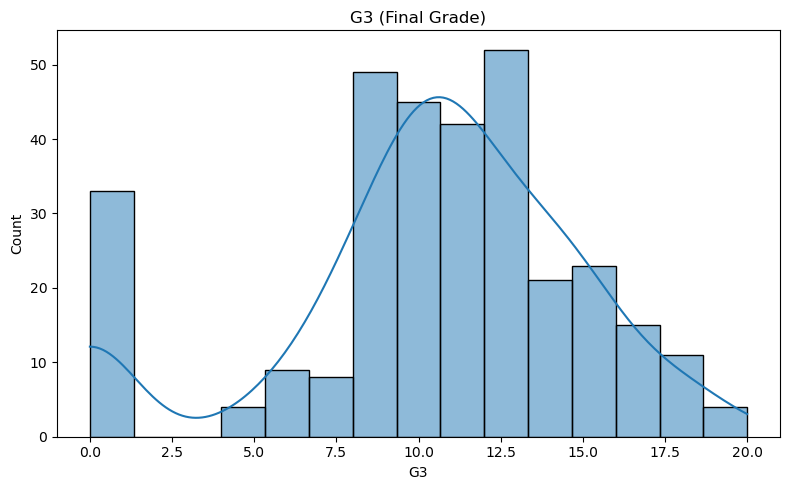

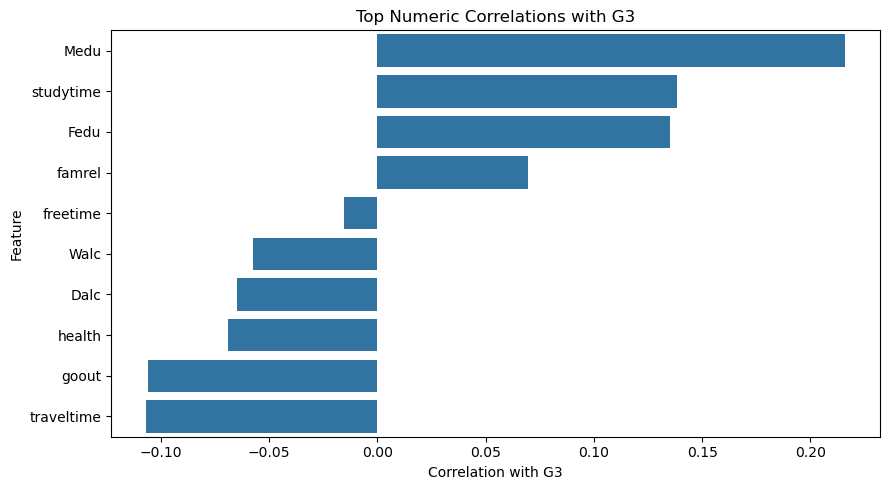

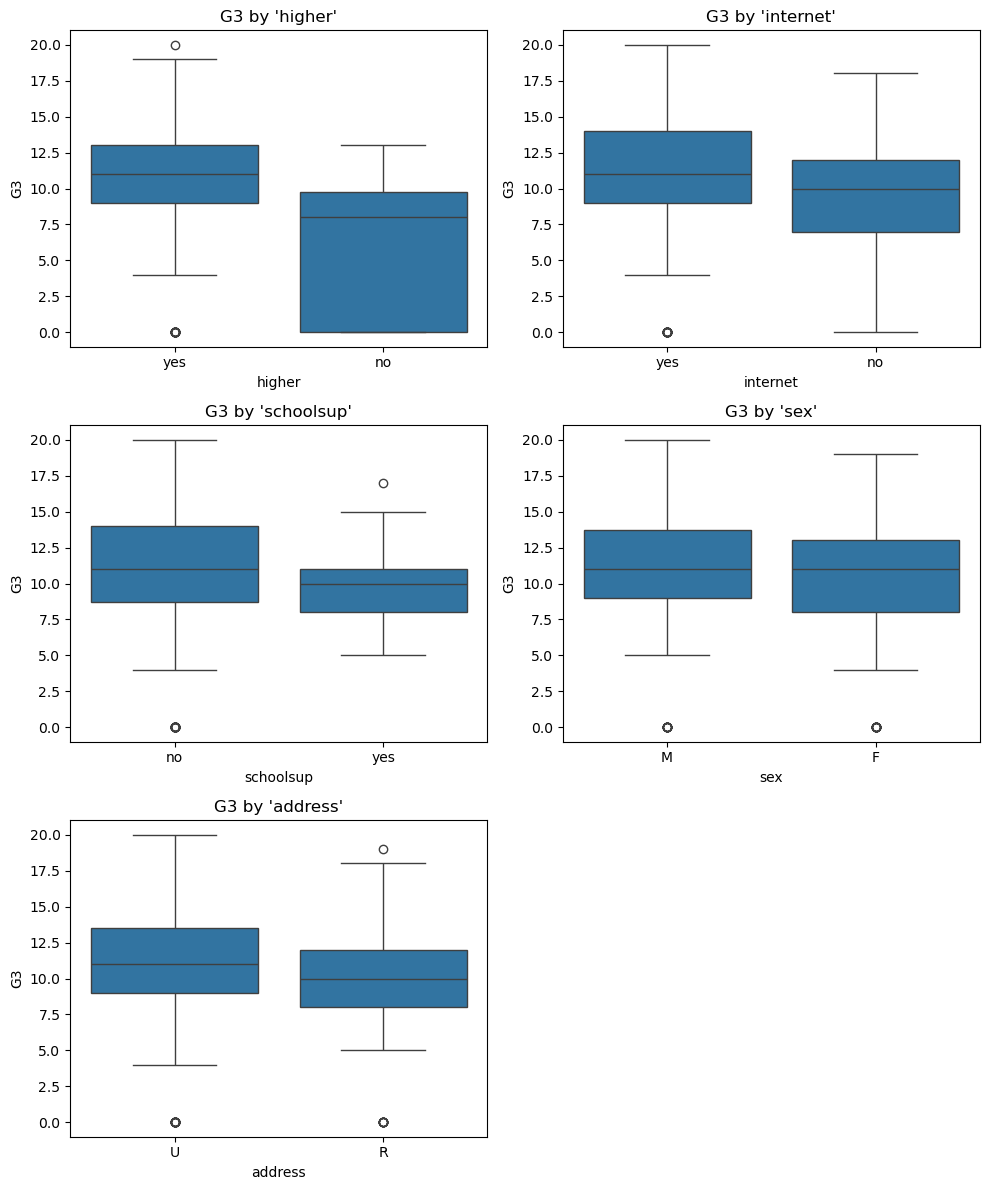

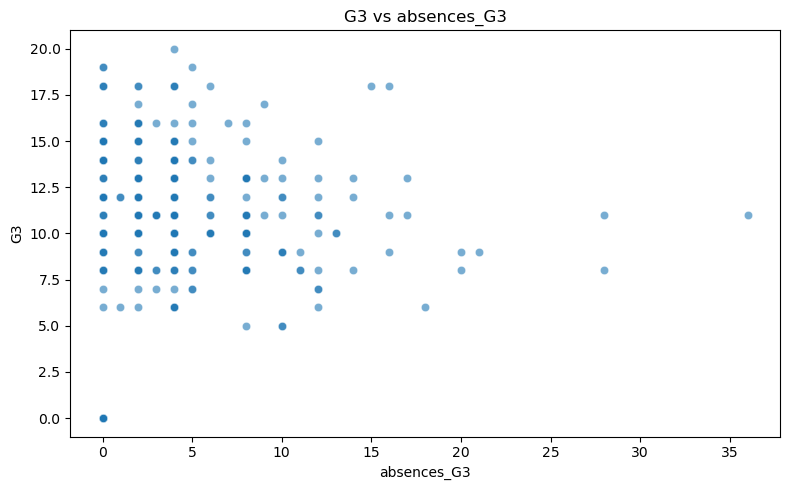

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Visualizations
cat_cols = [c for c in train_df.columns if train_df[c].dtype == "object"]
num_cols = [c for c in train_df.columns if c not in cat_cols]

# Plot 1 - Target Distribution
plt.figure(figsize=(8,5))
sns.histplot(train_df["G3"], bins=15, kde=True)
plt.title("G3 (Final Grade)")
plt.xlabel("G3")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot 2 - Top correlations
leak_cols = [c for c in ["G1","G2","absences_G1","absences_G2","absences_G3"] if c in train_df.columns]
strict_num = [c for c in num_cols if c not in leak_cols + ["G3"]]

corr_to_g3 = train_df[strict_num + ["G3"]].corr(numeric_only=True)["G3"].drop(labels=["G3"]).sort_values(ascending=False)

topk = corr_to_g3.head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=topk.values, y=topk.index, orient="h")
plt.title("Top Numeric Correlations with G3")
plt.xlabel("Correlation with G3")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Plot 3 - Boxplots of G3 by categorical data
candidates = [c for c in ["higher","internet","schoolsup","sex","address"] if c in cat_cols]
rows = math.ceil(len(candidates)/2)
fig, axes = plt.subplots(rows, 2, figsize=(10, 4*rows))
axes = axes.ravel()

for ax, c in zip(axes, candidates):
    sns.boxplot(data=train_df, x=c, y="G3", ax=ax)
    ax.set_title(f"G3 by '{c}'")
for ax in axes[len(candidates):]:
    ax.remove()
plt.tight_layout(); plt.show()

# Plot 4: Scatter of absences vs G3
abs_col = None
for c in ["absences_G3","absences_G2","absences_G1","absences"]:
    if c in train_df.columns:
        abs_col = c
        break

if abs_col is not None:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=train_df, x=abs_col, y="G3", alpha=0.6)
    plt.title(f"G3 vs {abs_col}")
    plt.xlabel(abs_col)
    plt.ylabel("G3")
    plt.tight_layout()
    plt.show()


In [5]:
#Correlations/Stats for each Plot

#Plot 1
g = train_df["G3"].dropna()
stats_g3 = {
    "count": int(g.size),
    "mean": float(g.mean()),
    "median": float(g.median()),
    "std": float(g.std(ddof=1)),
    "min": float(g.min()),
    "q1": float(g.quantile(0.25)),
    "q3": float(g.quantile(0.75)),
    "max": float(g.max()),
    "skew": float(g.skew()),  # >0 right-skew, <0 left-skew
    "floor_pct_(<=1)": float((g<=1).mean()),
    "ceiling_pct_(>=19)": float((g>=19).mean()),
}
print(stats_g3)

#Plot 2
print("\nTop 10 (non-leaky) correlations with G3:\n", corr_to_g3.head(10).round(3))

#Plot 3
candidates = ["higher","internet","schoolsup","sex","address"]
present = [c for c in candidates if c in train_df.columns]

for c in present:
    print(f"\nGroup stats for '{c}':")
    stats = (train_df.groupby(c)["G3"]
                .agg(count="size", mean="mean", median="median", std="std")
                .round(2))
    print(stats.to_string())

#Plot 4 - Pearson r
abs_col = "absences_G3" if "absences_G3" in train_df.columns else "absences"

xy = train_df[[abs_col, "G3"]].dropna()

xy.corr(numeric_only=True).loc[abs_col, "G3"]

{'count': 316, 'mean': 10.325949367088608, 'median': 11.0, 'std': 4.59033740682962, 'min': 0.0, 'q1': 8.0, 'q3': 13.0, 'max': 20.0, 'skew': -0.7763563136918057, 'floor_pct_(<=1)': 0.10443037974683544, 'ceiling_pct_(>=19)': 0.012658227848101266}

Top 10 (non-leaky) correlations with G3:
 Medu          0.216
studytime     0.138
Fedu          0.135
famrel        0.069
freetime     -0.015
Walc         -0.057
Dalc         -0.065
health       -0.069
goout        -0.106
traveltime   -0.107
Name: G3, dtype: float64

Group stats for 'higher':
        count   mean  median   std
higher                            
no         18   6.33     8.0  4.86
yes       298  10.57    11.0  4.47

Group stats for 'internet':
          count   mean  median   std
internet                            
no           51   9.08    10.0  4.46
yes         265  10.57    11.0  4.58

Group stats for 'schoolsup':
           count   mean  median   std
schoolsup                            
no           272  10.40    11.0  4.85

0.1144740679710407

## Prepare the Data

### Feature Selection

Based on your data exploration, begin considering the features you want to include in your model. Limiting your data can be beneficial because it reduces complexity and can improve model performance by focusing on the most relevant features.

Create lists below for the columns you want to use in your model based on your exploration above. These features will be used in the column transformer. The list names must match exactly.

- **numeric_columns**: This is your continuous numerical data that MUST include `absences_G1`, `absences_G2`, `absences_G3`, `G1`, and `G2` for use in your custom transformer, in addition to any other numerical columns you want to select. Note: The fact that a column is labeled as an integer or float does not necessarily indicate that it contains continuous data.
- **categorical_columns**: Include at least one categorical column.
- **ordinal_columns**: Include at least one ordinal column.

In [6]:
#Column Selection
cols = set(X_train.columns)

#numeric_columns
numeric_columns = [c for c in [
    "absences_G1", "absences_G2", "absences_G3", "G1", "G2", "failures", "age"
] if c in cols]

#categorical_columns
categorical_columns = [c for c in [
    "higher", "internet", "schoolsup", "address"
] if c in cols]

#ordinal_columns
ordinal_columns = [c for c in [
    "Medu", "Fedu", "studytime", "famrel"
] if c in cols]

### Custom Transformer
We want to create a new column that sums the three absences columns together as a new feature. Additionally, we want to  conditionally keep or drop the grades for the first and second terms based on the parameters passed.

G3 is the final year grade and is highly correlated with G2 and G1, which are grades from the first two terms. Predicting G3 without using G2 and G1 is more challenging but also more valuable since you could make predictions earlier in the year. Therefore, later we will create separate models (one that includes the G1 and G2 columns and one that excludes them) to test this.

#### Instructions for Submission

Create a custom transformer that:

- Inherits from BaseEstimator and TransformerMixin.
- Implements the fit and transform methods.
- Accepts a DataFrame as input. This differs from the California Housing Prices example, which used arrays. We will pass a DataFrame into the custom transformer.
- In the transform method:
    - Create a new column called `absences_sum` that sums the `absences_G1`, `absences_G2`, and `absences_G3` columns, adds the new `absences_sum` column to the end of the DataFrame, then drops the original three absence columns.
    - Drop the `G1` and `G2` columns if the parameter `drop_grades` is `True`. It will keep the columns if `drop_grades` is `False`.
- Name the custom transformer class `FinalProjectTransformer`.

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

#Custom transformer named FinalProjectTransformer
class FinalProjectTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, drop_grades: bool = True):
        self.drop_grades = drop_grades

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if not isinstance(X, pd.DataFrame):
            raise TypeError("FinalProjectTransformer expects a pandas DataFrame as input.")
        X = X.copy()

        #Create absences_sum
        abs_cols = ["absences_G1", "absences_G2", "absences_G3"]

        X["absences_sum"] = (X.filter(abs_cols).apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1))

        #Drop original absences columns
        X.drop(columns=[c for c in abs_cols if c in X.columns], errors="ignore", inplace=True)

        #Drop G1 and G2 is drop_grades is True
        if self.drop_grades:
            X.drop(columns=[c for c in ["G1", "G2"] if c in X.columns], errors="ignore", inplace=True)

        #Move absences_sum to end
        X = X[[c for c in X.columns if c != "absences_sum"] + ["absences_sum"]]
        return X

### Data Pipelines Instructions
Creating data pipelines allows you to automate your data cleaning process, making it easy to apply the same transformations to new data. Follow the outline below to transform your dataset into two sets of transformed data: one with the G1/G2 columns and one without them.

#### Instructions for Submission
- Numeric Pipeline (you'll need to create two to handle the G1/G2 requirement)
  - Impute missing values using SimpleImputer() (use [.set_output(transform="pandas")](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_set_output.html) to output a DataFrame from your SimpleImputer into your custom transformer) 
  - Transform data using the custom transformer FinalProjectTransformer as appropriate for the task
  - Standardize the data using StandardScalar()
  - Use the following variable names:
    - `numeric_pipeline_with_grades`
    - `numeric_pipeline_without_grades`

- Categorical Pipeline
  - Impute missing values 
  - One-Hot Encode (OHE) categorical data 
  - Use the following variable name:
    - `categorical_pipeline`

- Ordinal Pipeline
  - Impute missing values 
  - Ordinal encode the data
  - Use the following variable name:
    - `ordinal_pipeline`

- Column Transformer (you'll need to create two to handle the two different numeric pipelines)
  - pass in your previously created feature selection lists
  - Combine the numeric, categorical, and ordinal pipelines
  - Use the following variable names:
    - `column_transformer_with_grades`
    - `column_transformer_without_grades`
    
Once the full pipeline is set up, fit and transform `X_train`, saving the results as `X_train_transformed_with_grades` and `X_train_transformed_without_grades`. Confirm that the transformed data without grades has two fewer columns.

In [8]:
from packaging import version
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

#Numeric Pipeline with grades (keep G1 and G2)
numeric_pipeline_with_grades = Pipeline([
    ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
    ("fp", FinalProjectTransformer(drop_grades=False)),
    ("scaler", StandardScaler())
])

#Numeric Pipeline without grades (drop G1 and G2)
numeric_pipeline_without_grades = Pipeline([
    ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
    ("fp", FinalProjectTransformer(drop_grades=True)),
    ("scaler", StandardScaler())
])

#Categorical Pipeline
if version.parse(sklearn.__version__) >= version.parse("1.2"):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe),
])

#Ordinal Pipeline
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

#Column Transformers with grades
column_transformer_with_grades = ColumnTransformer([
    ("num", numeric_pipeline_with_grades, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns),
    ("ord", ordinal_pipeline, ordinal_columns),
], remainder="drop")

#Column Transformers without grades
column_transformer_without_grades = ColumnTransformer([
    ("num", numeric_pipeline_without_grades, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns),
    ("ord", ordinal_pipeline, ordinal_columns),
], remainder="drop")

#Fit and transform
X_train_transformed_with_grades = column_transformer_with_grades.fit_transform(X_train)
X_train_transformed_without_grades = column_transformer_without_grades.fit_transform(X_train)

In [9]:
#Confirm that the transformed data without grades has two fewer columns
print(X_train_transformed_with_grades.shape)
print(X_train_transformed_without_grades.shape)

(316, 17)
(316, 15)


## Modeling Strategy

Instead of building a single predictive model, two modeling pathways were developed:

1. A high-accuracy model including prior-term grades for later-stage intervention.
2. An early-warning model excluding grades to identify at-risk students earlier in the academic term.

This structure reflects real-world constraints where predictive features may not be available at the same time.

## Model Comparison and Cross-Validation
In this section, you will fit and compare three regression models to your transformed data, both with and without the G1/G2 columns, using cross-validation. Follow the steps below, using the specified variable names.

1) **Initialize Three Regression Models**
- Linear Regression
- Support Vector Machine (SVM) Regression
- Lasso Regression

2) **Compare Models with Cross-Validation**
- Using the above models, perform cross-validation on each model using both sets of transformed data (with and without G1/G2 columns).

### Instructions for Submission
1) **Initialize the Models**: Instantiate a Linear Regression, SVM Regression, and Lasso Regression model.
  - Use the specified variable names for the respective models:
    - `lin_reg`
    - `svm_reg`
    - `lasso_reg`
2) **Cross-Validation**: Using both sets of transformed data (with and without G1/G2 columns), perform 3-fold cross-validation for each model using RMSE as the metric.
  - You will run cross-validation six times (e.g., cross-validation of the linear regression model with the G1/G2 data, cross-validation of the linear regression model without the G1/G2 data, etc.)
  - Use the specified variable names to save each respective array of scores:
    - `cv_scores_lin_reg_with_grades`
    - `cv_scores_lin_reg_without_grades`
    - `cv_scores_svm_with_grades`
    - `cv_scores_svm_without_grades`
    - `cv_scores_lasso_with_grades`
    - `cv_scores_lasso_without_grades`
  - Use the specified variable names to save the mean of each cross-validation array and print it to view your mean scores:
    - `rmse_lin_reg_with_grades`
    - `rmse_lin_reg_without_grades`
    - `rmse_svm_with_grades`
    - `rmse_svm_without_grades`
    - `rmse_lasso_with_grades`
    - `rmse_lasso_without_grades`

*You are welcome to test and fit more regression models as long as the above three are included and named appropriately*

In [10]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

#1 Initialize the models
lin_reg = LinearRegression()
svm_reg = SVR(kernel="rbf")
lasso_reg = Lasso(alpha=1.0, max_iter=10000, random_state=42)

#2 Cross-Validation
cv3 = KFold(n_splits=3, shuffle=True, random_state=42)

def rmse_cv(estimator, X, y, cv):
    neg_mse = cross_val_score(estimator, X, y, cv=cv, scoring="neg_mean_squared_error")
    return np.sqrt(-neg_mse)

#With grades
cv_scores_lin_reg_with_grades = rmse_cv(lin_reg,  X_train_transformed_with_grades,  y_train, cv3)
cv_scores_svm_with_grades = rmse_cv(svm_reg,  X_train_transformed_with_grades,  y_train, cv3)
cv_scores_lasso_with_grades = rmse_cv(lasso_reg, X_train_transformed_with_grades, y_train, cv3)

rmse_lin_reg_with_grades = cv_scores_lin_reg_with_grades.mean()
rmse_svm_with_grades = cv_scores_svm_with_grades.mean()
rmse_lasso_with_grades = cv_scores_lasso_with_grades.mean()


#Without Grades
cv_scores_lin_reg_without_grades = rmse_cv(lin_reg,  X_train_transformed_without_grades,  y_train, cv3)
cv_scores_svm_without_grades = rmse_cv(svm_reg,  X_train_transformed_without_grades,  y_train, cv3)
cv_scores_lasso_without_grades = rmse_cv(lasso_reg, X_train_transformed_without_grades, y_train, cv3)

rmse_lin_reg_without_grades = cv_scores_lin_reg_without_grades.mean()
rmse_svm_without_grades = cv_scores_svm_without_grades.mean()
rmse_lasso_without_grades = cv_scores_lasso_without_grades.mean()

In [11]:
#Print to view mean scores
print("With grades")
print(f"Linear: {rmse_lin_reg_with_grades:.3f}")
print(f"SVM: {rmse_svm_with_grades:.3f}")
print(f"Lasso: {rmse_lasso_with_grades:.3f}")


print("\nWithout grades")
print(f"Linear: {rmse_lin_reg_without_grades:.3f}")
print(f"SVM: {rmse_svm_without_grades:.3f}")
print(f"Lasso: {rmse_lasso_without_grades:.3f}")

With grades
Linear: 1.872
SVM: 2.378
Lasso: 2.171

Without grades
Linear: 4.281
SVM: 4.274
Lasso: 4.381


## Hyperparameter Optimization
In this section, you will use the Support Vector Machine (SVM) regression model and perform grid search to fine-tune its hyperparameters. Follow the steps below to set up the grid search.

1) Set Up Grid Search for SVM Regression
  - Define a parameter grid to search over. Review Scikit-learn's documentation for the available hyperparameters for this algorithm.
  - Use GridSearchCV to find the best hyperparameters.
  - Fit the grid search to both sets (with and without the G1/G2 columns) of the transformed training data.

### Instructions for Submission

1) **Define Parameter Grid**: Set up a parameter grid for the SVM regression model name `param_grid`.
2) **Initialize Grid Search**: Initialize the `GridSearchCV` and call this `grid_search`.
3) **Fit the Grid Search**: Fit the grid search to both sets (with and without the G1/G2 columns) of the transformed training data.
4) **Save & Print Best Parameters**: Save the best parameters for each respective fit to `best_params_with_grades` and `best_params_without_grades`, and print them.
5) **Print Best Score**: Use the `best_score_` attribute to view the mean cross-validated score for each respective best_estimator
  

In [12]:
from sklearn.model_selection import GridSearchCV

#1 Define Parameter Grid
param_grid = {
    "kernel": ["rbf", "linear"],
    "C": [0.1, 1, 10],
    "epsilon": [0.1, 0.5, 1.0],
    "gamma": ["scale", "auto"]
}

#2 Initialize Grid Search
grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=0
)

#3 Fit to with grades
grid_search.fit(X_train_transformed_with_grades, y_train)
best_params_with_grades = grid_search.best_params_
best_score_with = grid_search.best_score_

print("With grades — best parameters:", best_params_with_grades)
print("With grades — best_score:", best_score_with)
print("With grades — best RMSE:", np.sqrt(-best_score_with))

#Reinitialize Grid Search
grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=0
)

#3 Fit to without grades
grid_search.fit(X_train_transformed_without_grades, y_train)
best_params_without_grades = grid_search.best_params_
best_score_without = grid_search.best_score_

print("\nWithout grades — best parameters:", best_params_without_grades)
print("Without grades — best_score:", best_score_without)
print("Without grades — best RMSE:", np.sqrt(-best_score_without))

With grades — best parameters: {'C': 10, 'epsilon': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
With grades — best_score: -3.5451430749499955
With grades — best RMSE: 1.8828550329087992

Without grades — best parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Without grades — best_score: -17.784514241280892
Without grades — best RMSE: 4.217168984197917


## Measure Performance on Test Set
In this section, you will transform the test set using your full pipeline and measure the performance of your best model on the test set. Follow the steps below.

1) Based on all previous cross-validation results, pick your best model.
2) Use the previously created column transformers to transform the test set, both with and without the G1/G2 columns.
3) Using your best model, measure its performance on the test set to estimate the generalization error.
  
### Instructions for Submission
1) **Fit Best Model**: If you haven't already, fit your best model to both sets of your transformed training data. 
2) **Transform the Test Set**: Use your column transformers to transform the test set (`X_test`), both with and without the G1/G2 columns. Name these transformed datasets `X_test_transformed_with_grades` and `X_test_transformed_without_grades`.
3) **Evaluate Performance**: Measure the performance of your best-fitted models on the transformed test sets using Root Mean Squared Error (RMSE) and R-squared (R²) metrics. Save these variables as:
  - `rmse_with_grades`
  - `r2_with_grades`
  - `rmse_without_grades`
  - `r2_without_grades`

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

#Fit Best Model with grades - Linear
best_with  = LinearRegression().fit(X_train_transformed_with_grades, y_train)

#Fit Best Model without grades (SVM)
svr_params = best_params_without_grades if "best_params_without_grades" in globals() else {"kernel": "rbf"}
best_without = SVR(**svr_params).fit(X_train_transformed_without_grades, y_train)

#Transform the test set
X_test_transformed_with_grades = column_transformer_with_grades.transform(X_test)
X_test_transformed_without_grades = column_transformer_without_grades.transform(X_test)

#Evaluate Performance
pred_with = best_with.predict(X_test_transformed_with_grades)
pred_without = best_without.predict(X_test_transformed_without_grades)

rmse_with_grades = float(mean_squared_error(y_test, pred_with, squared=False))
r2_with_grades = float(r2_score(y_test, pred_with))
rmse_without_grades = float(mean_squared_error(y_test, pred_without, squared=False))
r2_without_grades = float(r2_score(y_test, pred_without))

print(f"With grades -> RMSE={rmse_with_grades:.3f}  R²={r2_with_grades:.3f}")
print(f"Without grades -> RMSE={rmse_without_grades:.3f}  R²={r2_without_grades:.3f}")

With grades -> RMSE=2.142  R²=0.776
Without grades -> RMSE=4.154  R²=0.158


c:\Users\rharvey\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\rharvey\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Key Takeaways

- Including prior-term grades dramatically improves predictive accuracy.
- Early-year predictions remain valuable for risk identification even with reduced accuracy.
- Feature engineering and pipeline design had a larger impact on performance than model complexity.